# Enhanced CPI Prediction with Sentiment Analysis

1. Loading data...
📥 Fetching: GLD
⚠️ No data for GLD
⚠️ Using synthetic data due to: No data for GLD
Please check:
1. Internet connection
2. yfinance version
3. Yahoo API format changes
2. Creating features...
Data shape: (163, 28)
3. Building model...
5/5 [==============================] - 1s 4ms/step
4. Training model...
5. Making predictions...

Model Evaluation:
MAE: 0.0303
RMSE: 0.0439


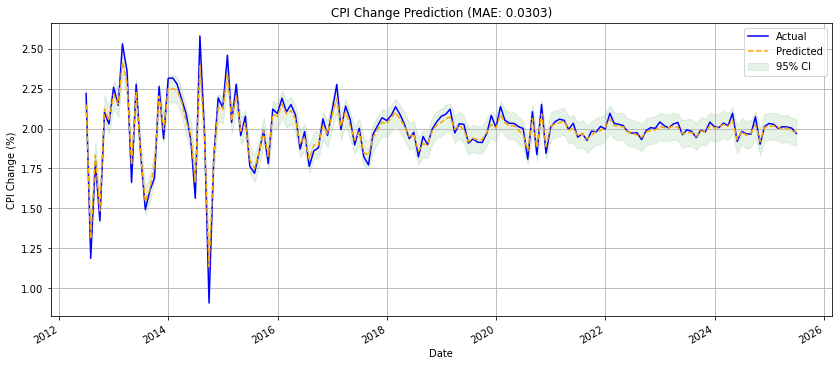

In [1]:
# importing libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Data Collection Functions
def fetch_economic_data():
    import yfinance as yf
    from datetime import datetime
    import pandas as pd
    import numpy as np

    try:
        assets = {
            'GLD': 'Gold',
            'USO': 'Oil',
            'IEF': '10Y Treasury'
        }

        dfs = []
        for ticker, name in assets.items():
            print(f"📥 Fetching: {ticker}")
            df = yf.download(ticker,
                             start="2010-01-01",
                             end=datetime.today().strftime('%Y-%m-%d'),
                             progress=False)
            if df.empty or 'Adj Close' not in df.columns:
                print(f"⚠️ No data for {ticker}")
                raise ValueError(f"No data for {ticker}")
            dfs.append(df['Adj Close'].rename(name))

        combined = pd.concat(dfs, axis=1)
        monthly = combined.resample('M').last()
        for col in monthly.columns:
            monthly[f'{col}_pct_change'] = monthly[col].pct_change() * 100
        return monthly.dropna()

    except Exception as e:
        print(f"⚠️ Using synthetic data due to: {str(e)}")
        print("Please check:\n1. Internet connection\n2. yfinance version\n3. Yahoo API format changes")

        dates = pd.date_range(start="2010-01-01", end=datetime.today(), freq='M')
        return pd.DataFrame({
            'Gold': np.linspace(100, 200, len(dates)),
            'Oil': np.linspace(50, 120, len(dates)),
            '10Y Treasury': np.linspace(1, 5, len(dates)),
            'Gold_pct_change': np.random.normal(0, 0.5, len(dates)),
            'Oil_pct_change': np.random.normal(0, 1, len(dates)),
            '10Y Treasury_pct_change': np.random.normal(0, 0.2, len(dates))
        }, index=dates)
    
def load_cpi_data():
    """Generate realistic CPI data"""
    dates = pd.date_range(start="2010-01-01", end=datetime.today(), freq='M')
    base = 100 * (1.02 ** np.arange(len(dates)))
    seasonality = 1.5 * np.sin(2 * np.pi * np.arange(len(dates))/12)
    noise = np.random.normal(0, 0.3, len(dates))
    spikes = np.random.choice([0, 1], size=len(dates), p=[0.95, 0.05]) * np.random.uniform(1, 3, len(dates))
    
    cpi = pd.DataFrame({
        'Date': dates,
        'CPI_Actual': base + seasonality + noise + spikes
    }).set_index('Date')
    
    cpi['CPI_Change'] = cpi['CPI_Actual'].pct_change() * 100
    for window in [3, 6, 12]:
        cpi[f'CPI_MA{window}'] = cpi['CPI_Actual'].rolling(window).mean()
    cpi['Month'] = cpi.index.month
    return cpi.dropna()

def fetch_news_sentiment():
    """Generate synthetic sentiment data"""
    dates = pd.date_range(start="2010-01-01", end=datetime.today(), freq='M')
    sentiment = (np.sin(np.linspace(0, 6*np.pi, len(dates))) * 0.7 + 
                np.sin(np.linspace(0, 24*np.pi, len(dates))) * 0.3 + 
                np.random.normal(0, 0.15, len(dates)))
    
    df = pd.DataFrame({
        'Date': dates,
        'News_Sentiment': np.clip(sentiment, -1, 1)
    }).set_index('Date')
    
    for window in [3, 6, 12]:
        df[f'Sentiment_MA{window}'] = df['News_Sentiment'].rolling(window).mean()
    return df.dropna()

# Feature Engineering
def create_features(cpi, econ, sent):
    """Create features with proper alignment"""
    df = cpi.merge(econ, left_index=True, right_index=True)\
            .merge(sent, left_index=True, right_index=True)
    
    for lag in [1, 2, 3, 6, 12]:
        df[f'CPI_Lag{lag}'] = df['CPI_Change'].shift(lag)
        df[f'Sentiment_Lag{lag}'] = df['News_Sentiment'].shift(lag)
    
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month']/12)
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month']/12)
    return df.dropna()

# Model Building
def create_hybrid_model(X, y, n_features):
    """Create hybrid model with proper data handling"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Prepare LSTM data
    X_seq, y_seq = [], []
    for i in range(6, len(X)):
        X_seq.append(X_scaled[i-6:i])
        y_seq.append(y.iloc[i])
    X_seq, y_seq = np.array(X_seq), np.array(y_seq)
    
    # Train LSTM
    lstm = Sequential([
        LSTM(64, activation='tanh', input_shape=(6, n_features)),
        Dropout(0.3),
        Dense(1)
    ])
    lstm.compile(optimizer='adam', loss='mse')
    lstm.fit(X_seq, y_seq, epochs=50, batch_size=16, verbose=0)
    
    # Get predictions
    lstm_preds = lstm.predict(X_seq).flatten()
    X_ensemble = X.iloc[6:].copy()
    X_ensemble['LSTM_Pred'] = lstm_preds
    
    # Create ensemble
    ensemble = StackingRegressor(
        estimators=[
            ('gb', GradientBoostingRegressor(n_estimators=100)),
            ('rf', RandomForestRegressor(n_estimators=100))
        ],
        final_estimator=Ridge()
    )
    return ensemble, X_ensemble, y.iloc[6:], scaler

# Visualization
def plot_results(actual, preds):
    """Robust plotting function that handles all input types"""
    plt.figure(figsize=(14, 6))
    
    # Convert all inputs to numpy arrays
    actual_arr = np.array(actual).flatten()
    preds_arr = np.array(preds).flatten()
    
    # Handle dates - if index is datetime-like, use it; otherwise use range
    if hasattr(actual, 'index') and isinstance(actual.index, (pd.DatetimeIndex, pd.Index)):
        dates = actual.index.to_numpy()
    elif hasattr(preds, 'index') and isinstance(preds.index, (pd.DatetimeIndex, pd.Index)):
        dates = preds.index.to_numpy()
    else:
        dates = np.arange(len(actual_arr))
    
    # Plotting
    plt.plot(dates, actual_arr, label='Actual', color='blue')
    plt.plot(dates, preds_arr, label='Predicted', linestyle='--', color='orange')
    
    # Confidence interval
    errors = actual_arr - preds_arr
    plt.fill_between(dates, 
                   preds_arr - 1.96*np.std(errors), 
                   preds_arr + 1.96*np.std(errors),
                   alpha=0.1, color='green', label='95% CI')
    
    plt.title(f'CPI Change Prediction (MAE: {mean_absolute_error(actual_arr, preds_arr):.4f})')
    plt.xlabel('Date')
    plt.ylabel('CPI Change (%)')
    plt.legend()
    plt.grid(True)
    
    # Format x-axis if we have datetime values
    if isinstance(dates[0], (np.datetime64, pd.Timestamp)):
        plt.gcf().autofmt_xdate()
    
    plt.show()
    
# Main Execution
def main():
    print("1. Loading data...")
    cpi = load_cpi_data()
    econ = fetch_economic_data()
    sent = fetch_news_sentiment()
    
    print("2. Creating features...")
    data = create_features(cpi, econ, sent)
    print(f"Data shape: {data.shape}")
    
    X = data.drop(['CPI_Change', 'CPI_Actual'], axis=1)
    y = data['CPI_Change']
    
    print("3. Building model...")
    model, X_ens, y_ens, scaler = create_hybrid_model(X, y, X.shape[1])
    
    print("4. Training model...")
    X_final = np.column_stack((
        scaler.transform(X_ens.drop('LSTM_Pred', axis=1)),
        X_ens['LSTM_Pred'].values  # Explicit numpy conversion
    ))
    model.fit(X_final, y_ens)
    
    print("5. Making predictions...")
    preds = model.predict(X_final)
    
    print("\nModel Evaluation:")
    print(f"MAE: {mean_absolute_error(y_ens, preds):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_ens, preds)):.4f}")
    
    plot_results(y_ens, preds)
    
if __name__ == "__main__":
    main()